In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load Stage 2 engineered dataset

file_path = "retail_inventory_stage2.csv"

df = pd.read_csv(file_path)

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (76000, 38)


In [3]:
# Quick inspection

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Month_Name,Week,Day,Day_Name,Day_of_Week,Quarter,Revenue,Discounted_Price,Net_Revenue,Inventory_Value,Inventory_Demand_Coverage,Inventory_to_Sales_Ratio,Order_to_Sales_Ratio,Order_Sales_Gap,Stockout_Flag,Demand_Exceeds_Inventory,Initial_Overstock_Flag,Initial_Inventory_Risk,Competitor_Price_Difference,Competitor_Price_Difference_Percent
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,January,52,1,Saturday,5,1,7417.44,69.084,7046.568,14180.40,1.695652,1.911765,2.470588,150,0,0,0,Healthy,-13.01,-15.175551
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,January,52,1,Saturday,5,1,9378.72,68.136,7971.912,9378.72,0.510917,1.000000,2.128205,132,0,1,0,Low Inventory,-11.86,-12.888502
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,January,52,1,Saturday,5,1,7175.16,56.646,6457.644,15546.18,1.573248,2.166667,5.368421,498,0,0,0,Healthy,2.86,4.760320
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,January,52,1,Saturday,5,1,3943.35,78.867,3549.015,12180.57,2.673077,3.088889,2.266667,57,0,0,0,Healthy,2.44,2.864186
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,January,52,1,Saturday,5,1,3536.65,54.410,3536.650,8270.32,2.576271,2.338462,4.169231,206,0,0,0,Healthy,2.78,5.384466


In [4]:
# Confirm key columns

print("Columns:")
print(df.columns.tolist())

Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand', 'Year', 'Month', 'Month_Name', 'Week', 'Day', 'Day_Name', 'Day_of_Week', 'Quarter', 'Revenue', 'Discounted_Price', 'Net_Revenue', 'Inventory_Value', 'Inventory_Demand_Coverage', 'Inventory_to_Sales_Ratio', 'Order_to_Sales_Ratio', 'Order_Sales_Gap', 'Stockout_Flag', 'Demand_Exceeds_Inventory', 'Initial_Overstock_Flag', 'Initial_Inventory_Risk', 'Competitor_Price_Difference', 'Competitor_Price_Difference_Percent']


## 1. Overall Business KPIs

In [5]:
# Overall KPIs

kpis = {
    "Total Records": len(df),
    "Total Units Sold": df["Units Sold"].sum(),
    "Total Demand": df["Demand"].sum(),
    "Total Revenue": df["Revenue"].sum(),
    "Total Net Revenue": df["Net_Revenue"].sum(),
    "Average Inventory": df["Inventory Level"].mean(),
    "Total Units Ordered": df["Units Ordered"].sum(),
    "Stockout Rate (%)": df["Stockout_Flag"].mean() * 100,
    "Demand > Inventory Rate (%)": df["Demand_Exceeds_Inventory"].mean() * 100,
    "Initial Overstock Rate (%)": df["Initial_Overstock_Flag"].mean() * 100
}

kpi_table = pd.Series(kpis).round(2)
kpi_table

Total Records                  7.600000e+04
Total Units Sold               6.750876e+06
Total Demand                   7.928104e+06
Total Revenue                  4.553001e+08
Total Net Revenue              4.125906e+08
Average Inventory              3.010600e+02
Total Units Ordered            6.770889e+06
Stockout Rate (%)              5.300000e-01
Demand > Inventory Rate (%)    1.368000e+01
Initial Overstock Rate (%)     4.197000e+01
dtype: float64

## 2. Demand Trend Analysis

In [6]:
# Daily demand

daily_demand = (
    df.groupby("Date")
    .agg(
        Total_Demand=("Demand", "sum"),
        Total_Units_Sold=("Units Sold", "sum")
    )
    .reset_index()
)

daily_demand.head()

,Date,Total_Demand,Total_Units_Sold
0,2022-01-01,10060,8601
1,2022-01-02,10814,7684
2,2022-01-03,11317,5965
3,2022-01-04,11469,7859
4,2022-01-05,11724,9621


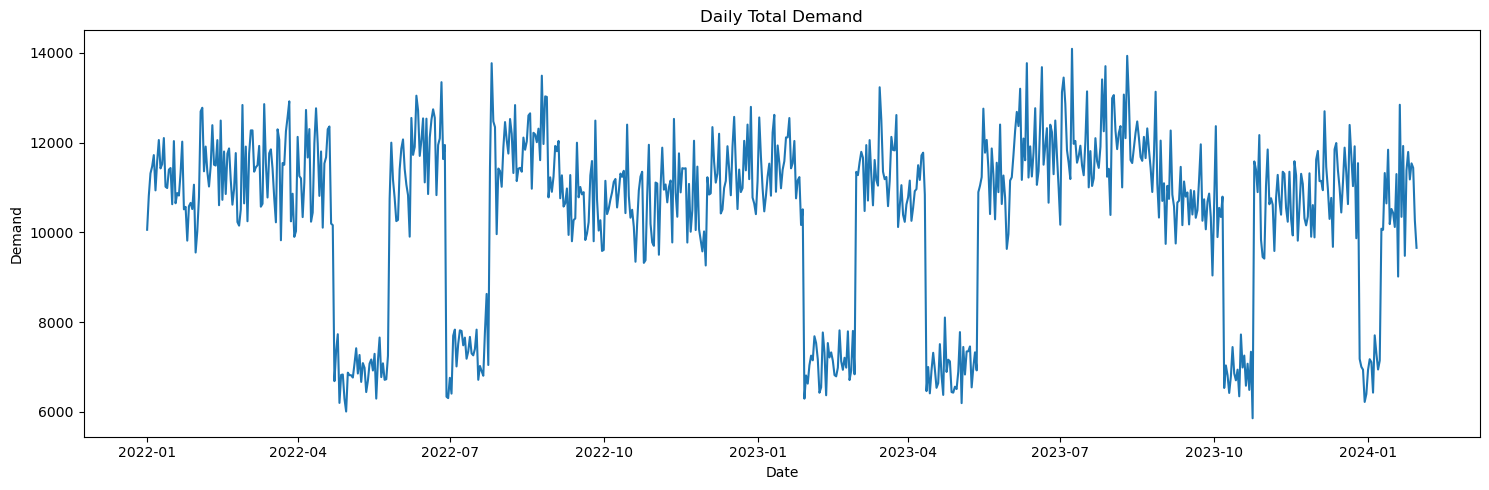

In [7]:
# Daily demand trend

plt.figure(figsize=(15, 5))

plt.plot(
    daily_demand["Date"],
    daily_demand["Total_Demand"]
)

plt.title("Daily Total Demand")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

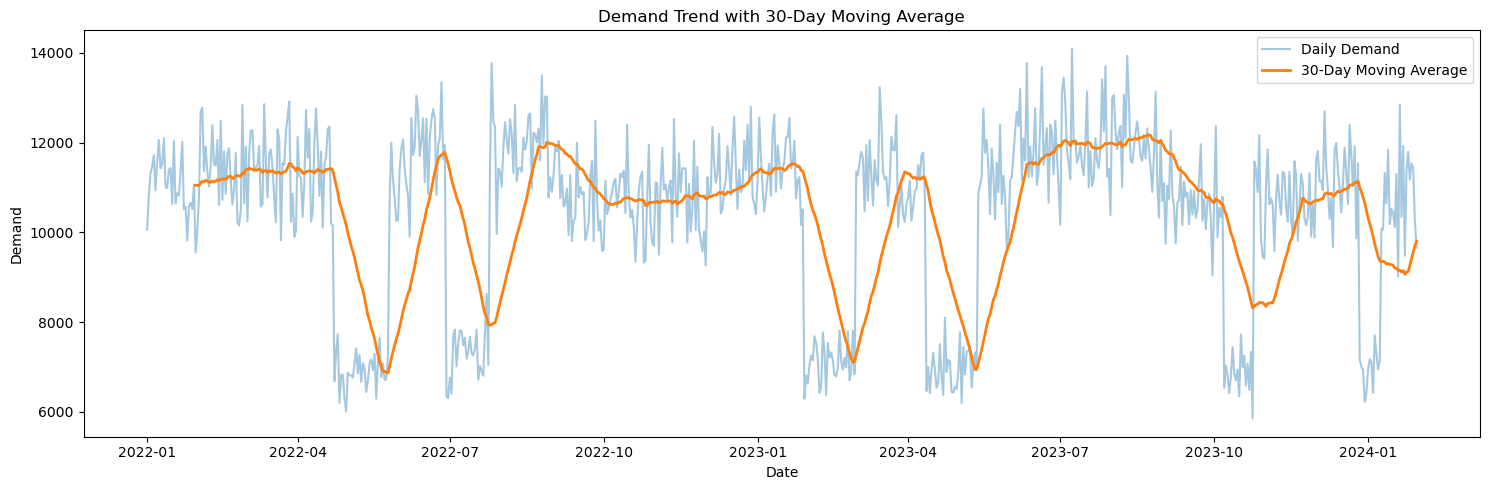

In [8]:
# 30-day rolling average demand

daily_demand["30_Day_Moving_Average"] = (
    daily_demand["Total_Demand"]
    .rolling(30)
    .mean()
)

plt.figure(figsize=(15, 5))

plt.plot(
    daily_demand["Date"],
    daily_demand["Total_Demand"],
    alpha=0.4,
    label="Daily Demand"
)

plt.plot(
    daily_demand["Date"],
    daily_demand["30_Day_Moving_Average"],
    linewidth=2,
    label="30-Day Moving Average"
)

plt.title("Demand Trend with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.tight_layout()
plt.show()

## 3. Monthly Demand & Seasonality

In [9]:
# Monthly demand

monthly_demand = (
    df.groupby(["Year", "Month"])
    .agg(
        Total_Demand=("Demand", "sum"),
        Total_Units_Sold=("Units Sold", "sum"),
        Average_Inventory=("Inventory Level", "mean")
    )
    .reset_index()
)

monthly_demand["Year_Month"] = (
    monthly_demand["Year"].astype(str)
    + "-"
    + monthly_demand["Month"].astype(str).str.zfill(2)
)

monthly_demand

,Year,Month,Total_Demand,Total_Units_Sold,Average_Inventory,Year_Month
0,2022,1,341544,283495,299.272258,2022-01
1,2022,2,319883,271108,322.022500,2022-02
2,2022,3,353173,303752,323.283871,2022-03
3,2022,4,305076,260812,311.067000,2022-04
4,2022,5,239112,205949,236.835161,2022-05
5,2022,6,345725,292816,325.022000,2022-06
6,2022,7,259736,220157,268.661290,2022-07
7,2022,8,370437,316705,329.760000,2022-08
8,2022,9,324264,277151,305.864667,2022-09
9,2022,10,329865,280227,299.438387,2022-10


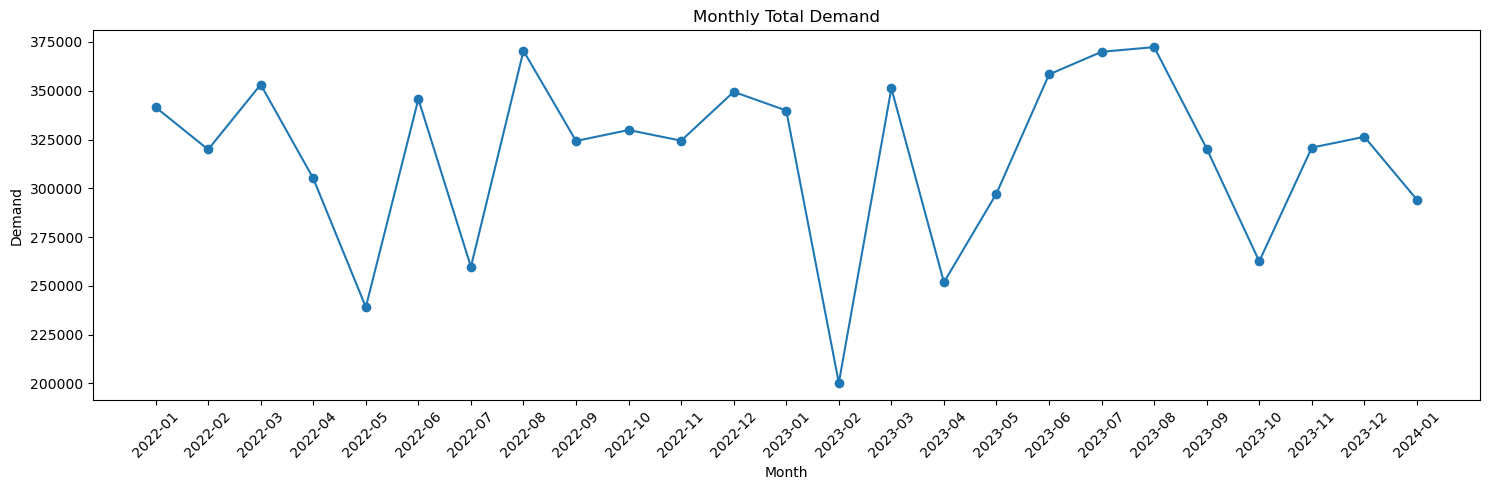

In [10]:
# Monthly demand trend

plt.figure(figsize=(15, 5))

plt.plot(
    monthly_demand["Year_Month"],
    monthly_demand["Total_Demand"],
    marker="o"
)

plt.title("Monthly Total Demand")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# Demand by month number

month_seasonality = (
    df.groupby("Month")
    .agg(
        Average_Demand=("Demand", "mean"),
        Total_Demand=("Demand", "sum"),
        Average_Units_Sold=("Units Sold", "mean")
    )
    .reset_index()
)

month_seasonality

,Month,Average_Demand,Total_Demand,Average_Units_Sold
0,1,106.040000,975568,89.343913
1,2,92.882500,520142,79.349107
2,3,113.613871,704406,96.813387
3,4,92.816667,556900,79.496333
4,5,86.521129,536431,73.953065
5,6,117.346000,704076,99.304333
6,7,101.561613,629682,86.056774
7,8,119.803387,742781,102.026935
8,9,107.431500,644589,92.192833
9,10,95.557258,592455,81.532419


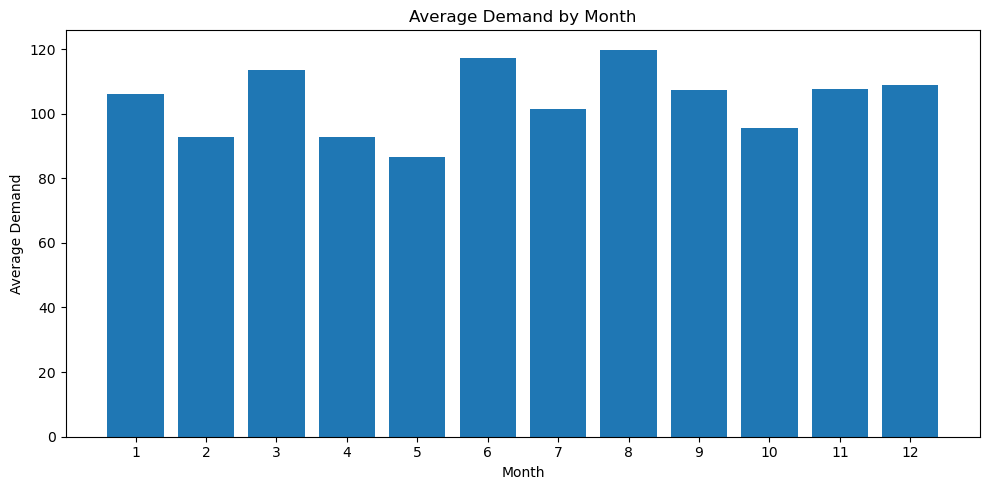

In [12]:
# Average demand by month

plt.figure(figsize=(10, 5))

plt.bar(
    month_seasonality["Month"],
    month_seasonality["Average_Demand"]
)

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [13]:
# Demand by season

season_demand = (
    df.groupby("Seasonality")
    .agg(
        Average_Demand=("Demand", "mean"),
        Total_Demand=("Demand", "sum"),
        Average_Units_Sold=("Units Sold", "mean")
    )
    .sort_values("Average_Demand", ascending=False)
)

season_demand

,Average_Demand,Total_Demand,Average_Units_Sold
Seasonality,,,
Summer,112.855380,2076539,95.757880
Autumn,103.422967,1882298,88.462637
Winter,103.406190,2171530,87.770524
Spring,97.703098,1797737,83.463587


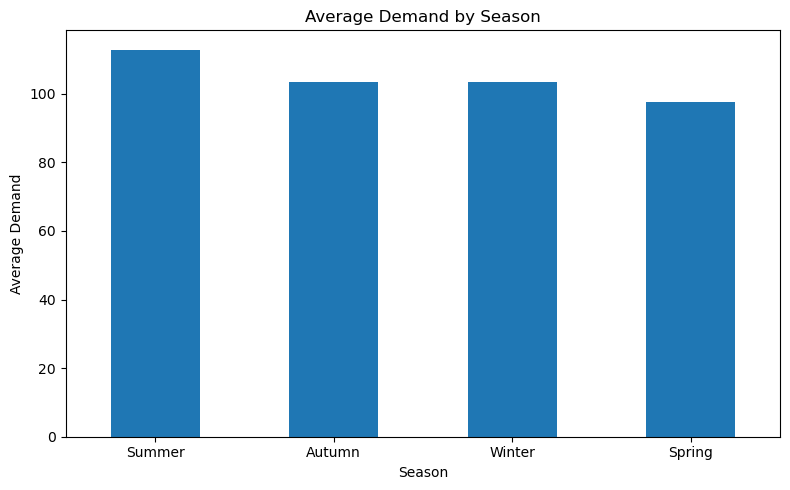

In [14]:
# Seasonal demand visualization

plt.figure(figsize=(8, 5))

season_demand["Average_Demand"].plot(kind="bar")

plt.title("Average Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Demand")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 4. Product Performance

In [15]:
# Product performance summary

product_performance = (
    df.groupby("Product ID")
    .agg(
        Total_Units_Sold=("Units Sold", "sum"),
        Total_Demand=("Demand", "sum"),
        Average_Inventory=("Inventory Level", "mean"),
        Total_Revenue=("Revenue", "sum"),
        Average_Price=("Price", "mean"),
        Average_Discount=("Discount", "mean"),
        Stockout_Rate=("Stockout_Flag", "mean"),
        Overstock_Rate=("Initial_Overstock_Flag", "mean")
    )
)

product_performance["Stockout_Rate"] *= 100
product_performance["Overstock_Rate"] *= 100

product_performance = product_performance.sort_values(
    "Total_Demand",
    ascending=False
)

product_performance.head(10)

,Total_Units_Sold,Total_Demand,Average_Inventory,Total_Revenue,Average_Price,Average_Discount,Stockout_Rate,Overstock_Rate
Product ID,,,,,,,,
P0009,376771,450324,272.303684,32556739.83,83.047739,8.985526,0.631579,30.552632
P0013,376717,440895,382.652632,17777490.87,44.303395,9.089474,0.657895,51.131579
P0004,377627,438505,320.350000,16904225.20,45.307184,9.148684,0.473684,40.815789
P0007,379709,437089,466.860000,14313694.35,35.674368,9.130263,0.605263,62.210526
P0002,359355,425853,285.830789,16360490.97,42.719934,9.084211,0.684211,39.289474
P0010,357299,422064,310.549474,23061113.11,66.468400,9.164474,0.526316,40.684211
P0001,356814,416447,331.758684,13973337.05,37.220403,9.176316,0.815789,45.552632
P0006,344589,409345,283.058421,17143242.91,46.914603,9.114474,0.578947,35.105263
P0005,351765,408578,392.904211,18456779.14,50.747358,9.157895,0.500000,52.710526


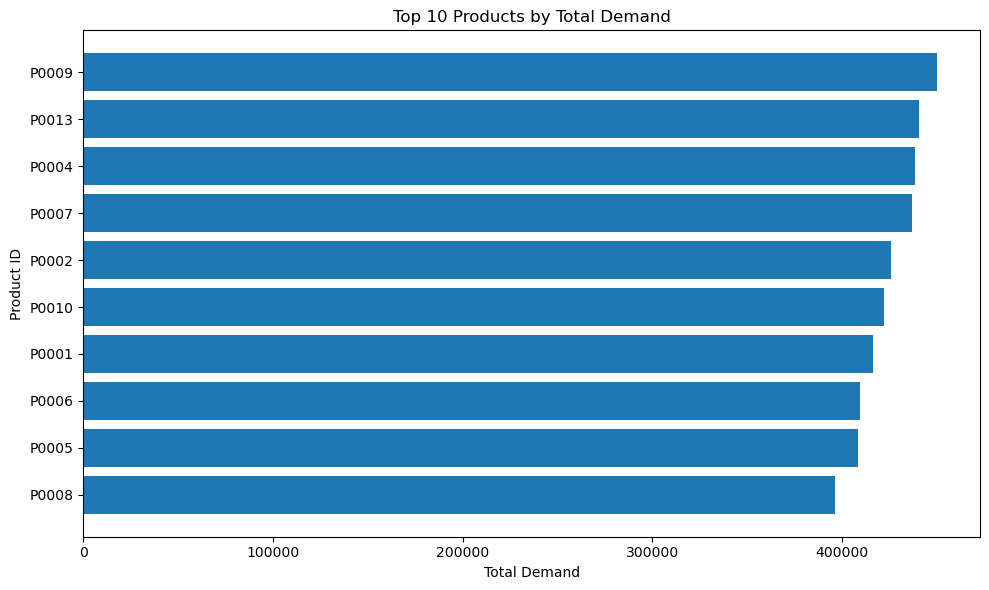

In [16]:
# Top 10 products by demand

top_products = product_performance.head(10).sort_values(
    "Total_Demand"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products.index.astype(str),
    top_products["Total_Demand"]
)

plt.title("Top 10 Products by Total Demand")
plt.xlabel("Total Demand")
plt.ylabel("Product ID")

plt.tight_layout()
plt.show()

In [17]:
# Products with highest stockout rates

highest_stockout_products = (
    product_performance
    .sort_values("Stockout_Rate", ascending=False)
    .head(10)
)

highest_stockout_products[[
    "Total_Demand",
    "Average_Inventory",
    "Stockout_Rate",
    "Overstock_Rate"
]]

,Total_Demand,Average_Inventory,Stockout_Rate,Overstock_Rate
Product ID,,,,
P0016,382874,289.913684,1.105263,46.289474
P0011,382766,345.631053,0.842105,54.026316
P0001,416447,331.758684,0.815789,45.552632
P0002,425853,285.830789,0.684211,39.289474
P0015,389468,340.976316,0.684211,49.973684
P0013,440895,382.652632,0.657895,51.131579
P0009,450324,272.303684,0.631579,30.552632
P0020,320847,283.483158,0.605263,50.421053
P0007,437089,466.860000,0.605263,62.210526


In [18]:
# Products with highest overstock rates

highest_overstock_products = (
    product_performance
    .sort_values("Overstock_Rate", ascending=False)
    .head(10)
)

highest_overstock_products[[
    "Total_Demand",
    "Average_Inventory",
    "Stockout_Rate",
    "Overstock_Rate"
]]

,Total_Demand,Average_Inventory,Stockout_Rate,Overstock_Rate
Product ID,,,,
P0007,437089,466.860000,0.605263,62.210526
P0014,364335,339.902895,0.552632,55.842105
P0011,382766,345.631053,0.842105,54.026316
P0005,408578,392.904211,0.500000,52.710526
P0013,440895,382.652632,0.657895,51.131579
P0020,320847,283.483158,0.605263,50.421053
P0015,389468,340.976316,0.684211,49.973684
P0012,347215,289.895789,0.289474,46.842105
P0016,382874,289.913684,1.105263,46.289474


## 5. Store Performance

In [19]:
# Store performance

store_performance = (
    df.groupby("Store ID")
    .agg(
        Total_Units_Sold=("Units Sold", "sum"),
        Total_Demand=("Demand", "sum"),
        Average_Inventory=("Inventory Level", "mean"),
        Total_Revenue=("Revenue", "sum"),
        Stockout_Rate=("Stockout_Flag", "mean"),
        Overstock_Rate=("Initial_Overstock_Flag", "mean")
    )
)

store_performance["Stockout_Rate"] *= 100
store_performance["Overstock_Rate"] *= 100

store_performance

,Total_Units_Sold,Total_Demand,Average_Inventory,Total_Revenue,Stockout_Rate,Overstock_Rate
Store ID,,,,,,
S001,1318134,1547573,277.657368,89854451.03,0.388158,37.809211
S002,1386126,1625471,332.014737,92298840.07,0.611842,47.203947
S003,1375613,1618324,321.993026,98526308.33,0.559211,44.375000
S004,1308191,1529651,293.244211,94466923.20,0.513158,41.203947
S005,1362812,1607085,280.404868,80153571.87,0.598684,39.236842


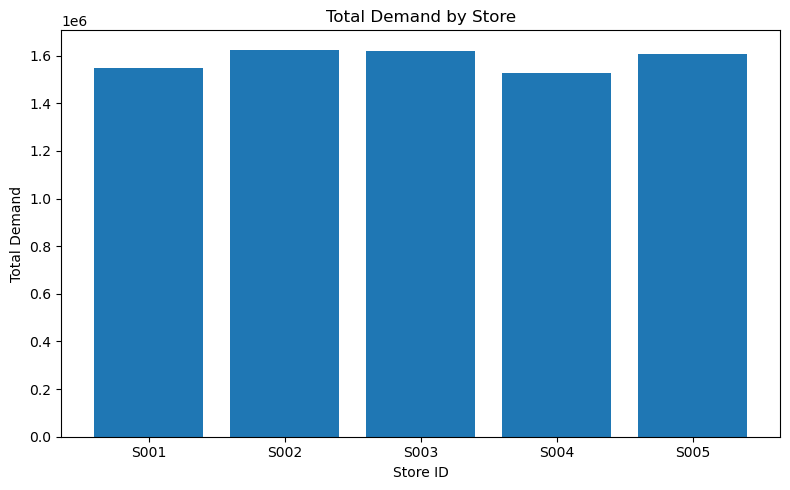

In [20]:
# Store demand comparison

plt.figure(figsize=(8, 5))

plt.bar(
    store_performance.index.astype(str),
    store_performance["Total_Demand"]
)

plt.title("Total Demand by Store")
plt.xlabel("Store ID")
plt.ylabel("Total Demand")

plt.tight_layout()
plt.show()

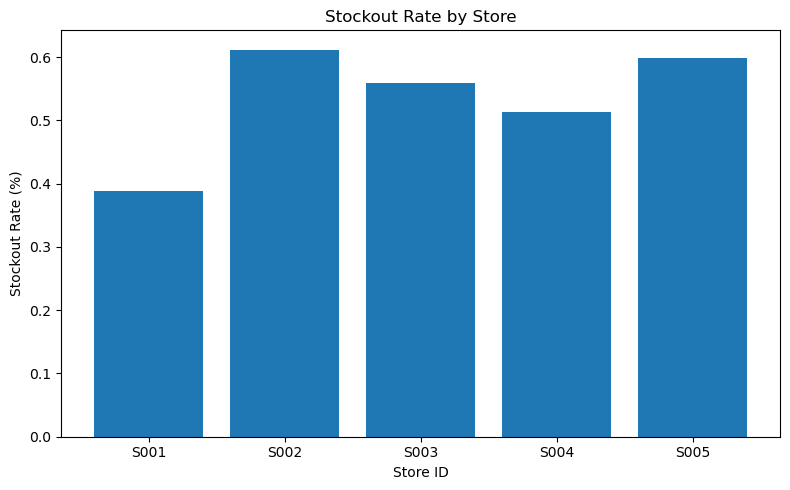

In [21]:
# Store stockout rate

plt.figure(figsize=(8, 5))

plt.bar(
    store_performance.index.astype(str),
    store_performance["Stockout_Rate"]
)

plt.title("Stockout Rate by Store")
plt.xlabel("Store ID")
plt.ylabel("Stockout Rate (%)")

plt.tight_layout()
plt.show()

## 6. Regional Performance

In [22]:
# Regional performance

region_performance = (
    df.groupby("Region")
    .agg(
        Total_Units_Sold=("Units Sold", "sum"),
        Total_Demand=("Demand", "sum"),
        Average_Inventory=("Inventory Level", "mean"),
        Total_Revenue=("Revenue", "sum"),
        Stockout_Rate=("Stockout_Flag", "mean"),
        Overstock_Rate=("Initial_Overstock_Flag", "mean")
    )
)

region_performance["Stockout_Rate"] *= 100
region_performance["Overstock_Rate"] *= 100

region_performance

,Total_Units_Sold,Total_Demand,Average_Inventory,Total_Revenue,Stockout_Rate,Overstock_Rate
Region,,,,,,
East,1375613,1618324,321.993026,9.852631e+07,0.559211,44.375000
North,2680946,3154658,279.031118,1.700080e+08,0.493421,38.523026
South,1386126,1625471,332.014737,9.229884e+07,0.611842,47.203947
West,1308191,1529651,293.244211,9.446692e+07,0.513158,41.203947


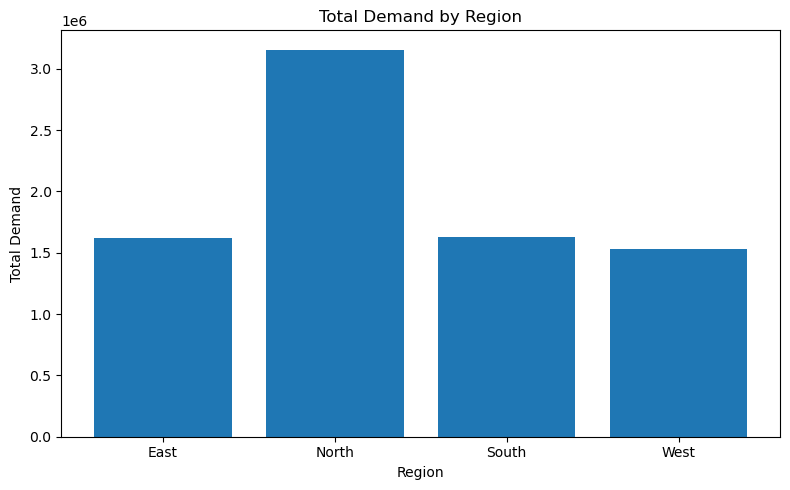

In [23]:
# Regional demand

plt.figure(figsize=(8, 5))

plt.bar(
    region_performance.index.astype(str),
    region_performance["Total_Demand"]
)

plt.title("Total Demand by Region")
plt.xlabel("Region")
plt.ylabel("Total Demand")

plt.tight_layout()
plt.show()

## 7. Stockout Analysis

In [24]:
# Stockout analysis by category

stockout_category = (
    df.groupby("Category")
    .agg(
        Stockout_Rate=("Stockout_Flag", "mean"),
        Demand=("Demand", "sum"),
        Average_Inventory=("Inventory Level", "mean")
    )
)

stockout_category["Stockout_Rate"] *= 100

stockout_category.sort_values(
    "Stockout_Rate",
    ascending=False
)

,Stockout_Rate,Demand,Average_Inventory
Category,,,
Groceries,0.684211,3677684,360.314770
Electronics,0.504386,889036,289.260417
Toys,0.479323,985338,229.111748
Clothing,0.452303,1369456,282.103536
Furniture,0.336257,1006590,250.074854


In [25]:
# Stockout analysis by region

stockout_region = (
    df.groupby("Region")
    .agg(
        Stockout_Rate=("Stockout_Flag", "mean"),
        Demand=("Demand", "sum"),
        Average_Inventory=("Inventory Level", "mean")
    )
)

stockout_region["Stockout_Rate"] *= 100

stockout_region.sort_values(
    "Stockout_Rate",
    ascending=False
)

,Stockout_Rate,Demand,Average_Inventory
Region,,,
South,0.611842,1625471,332.014737
East,0.559211,1618324,321.993026
West,0.513158,1529651,293.244211
North,0.493421,3154658,279.031118


In [26]:
# Demand exceeding inventory by category

demand_pressure_category = (
    df.groupby("Category")
    .agg(
        Demand_Exceeds_Inventory_Rate=(
            "Demand_Exceeds_Inventory",
            "mean"
        ),
        Total_Demand=("Demand", "sum"),
        Average_Inventory=("Inventory Level", "mean")
    )
)

demand_pressure_category["Demand_Exceeds_Inventory_Rate"] *= 100

demand_pressure_category.sort_values(
    "Demand_Exceeds_Inventory_Rate",
    ascending=False
)

,Demand_Exceeds_Inventory_Rate,Total_Demand,Average_Inventory
Category,,,
Clothing,19.424342,1369456,282.103536
Toys,14.971805,985338,229.111748
Electronics,13.870614,889036,289.260417
Groceries,13.490132,3677684,360.314770
Furniture,7.843567,1006590,250.074854


## 8. Overstock Analysis

In [27]:
# Overstock by category

overstock_category = (
    df.groupby("Category")
    .agg(
        Overstock_Rate=("Initial_Overstock_Flag", "mean"),
        Average_Inventory=("Inventory Level", "mean"),
        Average_Demand=("Demand", "mean")
    )
)

overstock_category["Overstock_Rate"] *= 100

overstock_category.sort_values(
    "Overstock_Rate",
    ascending=False
)

,Overstock_Rate,Average_Inventory,Average_Demand
Category,,,
Furniture,51.959064,250.074854,73.581140
Groceries,43.694079,360.314770,120.976447
Electronics,42.554825,289.260417,97.482018
Toys,35.441729,229.111748,92.606955
Clothing,31.669408,282.103536,112.619737


In [28]:
# Overstock by store

overstock_store = (
    df.groupby("Store ID")
    .agg(
        Overstock_Rate=("Initial_Overstock_Flag", "mean"),
        Average_Inventory=("Inventory Level", "mean"),
        Average_Demand=("Demand", "mean")
    )
)

overstock_store["Overstock_Rate"] *= 100

overstock_store.sort_values(
    "Overstock_Rate",
    ascending=False
)

,Overstock_Rate,Average_Inventory,Average_Demand
Store ID,,,
S002,47.203947,332.014737,106.938882
S003,44.375000,321.993026,106.468684
S004,41.203947,293.244211,100.634934
S005,39.236842,280.404868,105.729276
S001,37.809211,277.657368,101.814013


## 9. Promotion Impact on Demand

In [29]:
# Promotion comparison

promotion_analysis = (
    df.groupby("Promotion")
    .agg(
        Average_Demand=("Demand", "mean"),
        Median_Demand=("Demand", "median"),
        Total_Demand=("Demand", "sum"),
        Average_Units_Sold=("Units Sold", "mean"),
        Average_Discount=("Discount", "mean"),
        Average_Revenue=("Revenue", "mean")
    )
)

promotion_analysis

,Average_Demand,Median_Demand,Total_Demand,Average_Units_Sold,Average_Discount,Average_Revenue
Promotion,,,,,,
0,95.026843,92.0,4846369,81.833314,4.983333,5604.608655
1,123.269400,120.0,3081735,103.095080,17.458600,6778.602124


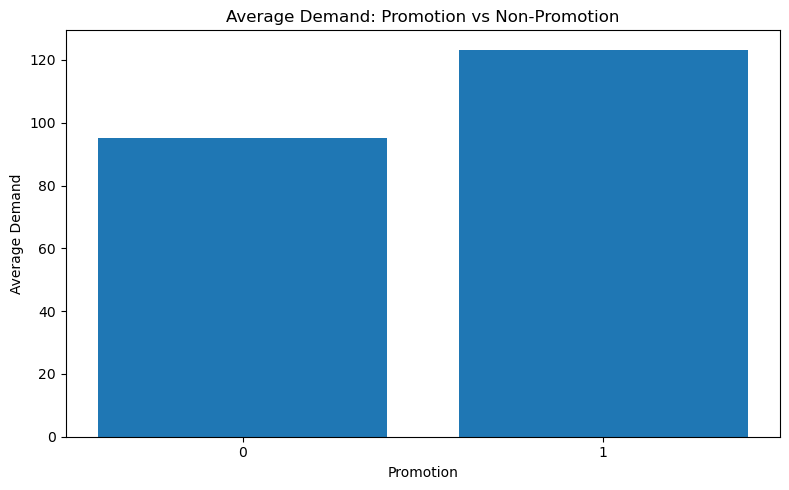

In [30]:
# Promotion vs non-promotion demand

plt.figure(figsize=(8, 5))

plt.bar(
    promotion_analysis.index.astype(str),
    promotion_analysis["Average_Demand"]
)

plt.title("Average Demand: Promotion vs Non-Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## 10. Weather Impact

In [31]:
# Weather vs demand

weather_analysis = (
    df.groupby("Weather Condition")
    .agg(
        Average_Demand=("Demand", "mean"),
        Total_Demand=("Demand", "sum"),
        Average_Units_Sold=("Units Sold", "mean"),
        Average_Inventory=("Inventory Level", "mean")
    )
    .sort_values("Average_Demand", ascending=False)
)

weather_analysis

,Average_Demand,Total_Demand,Average_Units_Sold,Average_Inventory
Weather Condition,,,,
Sunny,115.167189,2646542,97.027937,300.241601
Cloudy,105.404064,2567643,89.625369,301.557800
Rainy,95.106743,1664368,81.972286,302.547943
Snowy,94.045789,1049551,80.948477,299.344713


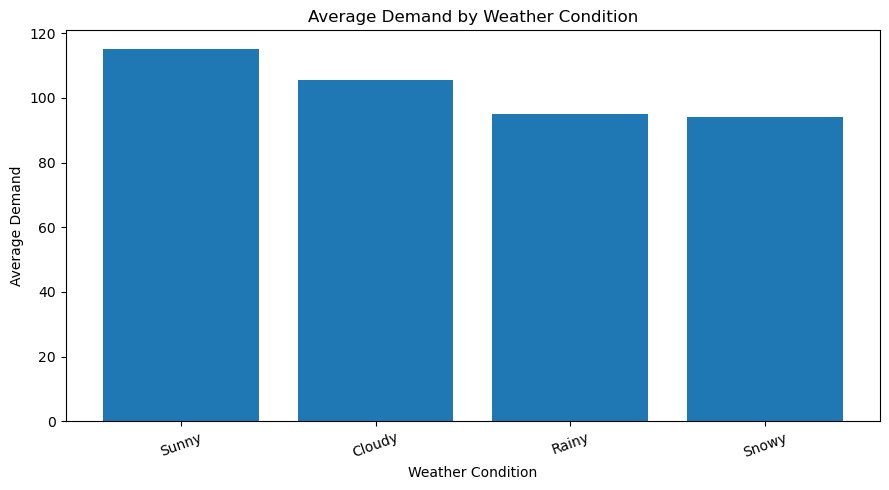

In [32]:
# Weather demand visualization

plt.figure(figsize=(9, 5))

plt.bar(
    weather_analysis.index.astype(str),
    weather_analysis["Average_Demand"]
)

plt.title("Average Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Demand")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 11. Competitor Pricing Analysis

In [33]:
# Price position

df["Price_Position"] = np.select(
    [
        df["Price"] < df["Competitor Pricing"],
        df["Price"] > df["Competitor Pricing"]
    ],
    [
        "Lower than Competitor",
        "Higher than Competitor"
    ],
    default="Same as Competitor"
)

price_position_analysis = (
    df.groupby("Price_Position")
    .agg(
        Average_Demand=("Demand", "mean"),
        Average_Units_Sold=("Units Sold", "mean"),
        Average_Price=("Price", "mean"),
        Average_Competitor_Price=("Competitor Pricing", "mean")
    )
)

price_position_analysis

,Average_Demand,Average_Units_Sold,Average_Price,Average_Competitor_Price
Price_Position,,,,
Higher than Competitor,104.351049,88.742344,69.356333,64.162458
Lower than Competitor,104.289877,88.920710,66.104319,74.813900
Same as Competitor,97.270270,80.945946,44.970541,44.970541


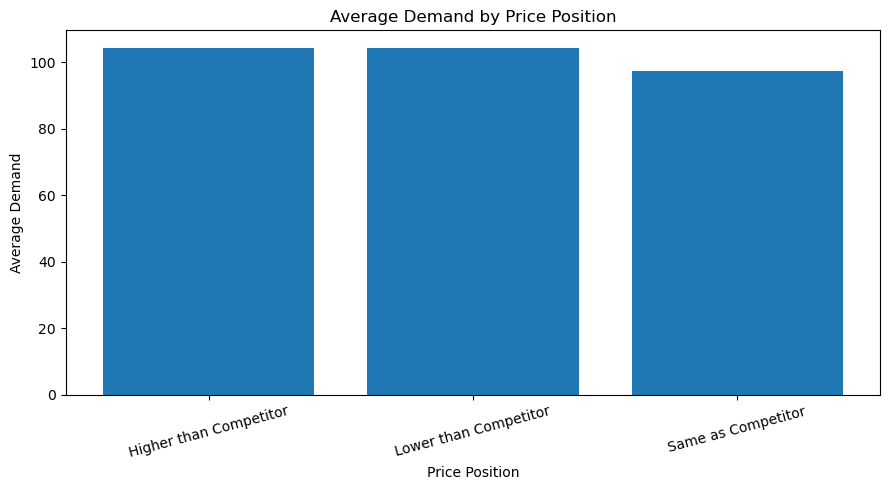

In [34]:
# Demand by price position

plt.figure(figsize=(9, 5))

plt.bar(
    price_position_analysis.index,
    price_position_analysis["Average_Demand"]
)

plt.title("Average Demand by Price Position")
plt.xlabel("Price Position")
plt.ylabel("Average Demand")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## 12. Inventory Turnover — Exploratory

In [35]:
# Product-level inventory turnover proxy

# This is an exploratory turnover proxy because the dataset
# does not provide cost of goods sold or average inventory
# accounting values.

turnover = (
    df.groupby("Product ID")
    .agg(
        Total_Units_Sold=("Units Sold", "sum"),
        Average_Inventory=("Inventory Level", "mean")
    )
)

turnover["Inventory_Turnover_Proxy"] = np.where(
    turnover["Average_Inventory"] > 0,
    turnover["Total_Units_Sold"] / turnover["Average_Inventory"],
    np.nan
)

turnover.sort_values(
    "Inventory_Turnover_Proxy",
    ascending=False
).head(10)

,Total_Units_Sold,Average_Inventory,Inventory_Turnover_Proxy
Product ID,,,
P0008,323317,151.431316,2135.073570
P0018,310597,185.831842,1671.387403
P0019,313209,212.485526,1474.025104
P0009,376771,272.303684,1383.642682
P0017,294918,225.173684,1309.735643
P0002,359355,285.830789,1257.229848
P0006,344589,283.058421,1217.377666
P0004,377627,320.350000,1178.795068
P0010,357299,310.549474,1150.538095


### Interpretation note

This is **not the standard accounting inventory-turnover ratio** because we do not have COGS and accounting-period average inventory.

We are explicitly calling it a **turnover proxy** for exploratory analysis. A more rigorous version can be developed later if the required cost information is available.

## 13. Demand Variability

In [36]:
# Demand variability by product

demand_variability = (
    df.groupby("Product ID")["Demand"]
    .agg(
        Average_Demand="mean",
        Demand_Std="std",
        Minimum_Demand="min",
        Maximum_Demand="max"
    )
)

demand_variability["Coefficient_of_Variation"] = np.where(
    demand_variability["Average_Demand"] > 0,
    demand_variability["Demand_Std"] /
    demand_variability["Average_Demand"],
    np.nan
)

demand_variability.sort_values(
    "Coefficient_of_Variation",
    ascending=False
).head(10)

,Average_Demand,Demand_Std,Minimum_Demand,Maximum_Demand,Coefficient_of_Variation
Product ID,,,,,
P0017,92.268421,44.254071,4,319,0.479623
P0020,84.433421,39.696947,4,295,0.470157
P0014,95.877632,44.430241,4,328,0.463406
P0018,99.264474,45.749611,4,328,0.460886
P0016,100.756316,46.411025,4,378,0.460626
P0015,102.491579,47.096809,4,369,0.459519
P0012,91.372368,41.818942,4,300,0.457676
P0003,103.995263,46.690876,4,324,0.448971
P0019,97.882632,43.761371,4,333,0.447080


## 14. High-Demand + High-Risk Products

In [37]:
# Combine demand and inventory risk at product level

risk_product_analysis = (
    df.groupby("Product ID")
    .agg(
        Total_Demand=("Demand", "sum"),
        Average_Inventory=("Inventory Level", "mean"),
        Stockout_Rate=("Stockout_Flag", "mean"),
        Demand_Exceeds_Inventory_Rate=(
            "Demand_Exceeds_Inventory",
            "mean"
        ),
        Overstock_Rate=("Initial_Overstock_Flag", "mean"),
        Total_Revenue=("Revenue", "sum")
    )
)

risk_product_analysis["Stockout_Rate"] *= 100
risk_product_analysis["Demand_Exceeds_Inventory_Rate"] *= 100
risk_product_analysis["Overstock_Rate"] *= 100

risk_product_analysis

,Total_Demand,Average_Inventory,Stockout_Rate,Demand_Exceeds_Inventory_Rate,Overstock_Rate,Total_Revenue
Product ID,,,,,,
P0001,416447,331.758684,0.815789,9.631579,45.552632,13973337.05
P0002,425853,285.830789,0.684211,14.157895,39.289474,16360490.97
P0003,395182,310.263684,0.342105,11.210526,43.578947,26332779.37
P0004,438505,320.350000,0.473684,12.131579,40.815789,16904225.20
P0005,408578,392.904211,0.500000,10.947368,52.710526,18456779.14
P0006,409345,283.058421,0.578947,17.210526,35.105263,17143242.91
P0007,437089,466.860000,0.605263,6.210526,62.210526,14313694.35
P0008,396538,151.431316,0.131579,28.394737,11.605263,22103886.20
P0009,450324,272.303684,0.631579,18.578947,30.552632,32556739.83


In [38]:
# Create a simple exploratory high-priority flag

demand_threshold = risk_product_analysis["Total_Demand"].median()
stockout_threshold = risk_product_analysis["Stockout_Rate"].median()

risk_product_analysis["High_Demand_High_Stockout"] = np.where(
    (risk_product_analysis["Total_Demand"] >= demand_threshold) &
    (risk_product_analysis["Stockout_Rate"] >= stockout_threshold),
    "High Priority",
    "Other"
)

risk_product_analysis.sort_values(
    ["High_Demand_High_Stockout", "Total_Demand"],
    ascending=[True, False]
).head(10)

,Total_Demand,Average_Inventory,Stockout_Rate,Demand_Exceeds_Inventory_Rate,Overstock_Rate,Total_Revenue,High_Demand_High_Stockout
Product ID,,,,,,,
P0009,450324,272.303684,0.631579,18.578947,30.552632,32556739.83,High Priority
P0013,440895,382.652632,0.657895,10.157895,51.131579,17777490.87,High Priority
P0007,437089,466.860000,0.605263,6.210526,62.210526,14313694.35,High Priority
P0002,425853,285.830789,0.684211,14.157895,39.289474,16360490.97,High Priority
P0001,416447,331.758684,0.815789,9.631579,45.552632,13973337.05,High Priority
P0006,409345,283.058421,0.578947,17.210526,35.105263,17143242.91,High Priority
P0004,438505,320.350000,0.473684,12.131579,40.815789,16904225.20,Other
P0010,422064,310.549474,0.526316,18.184211,40.684211,23061113.11,Other
P0005,408578,392.904211,0.500000,10.947368,52.710526,18456779.14,Other


## 15. Business Insight Tables

In [39]:
# Top products by demand

top_demand_products = (
    product_performance
    .sort_values("Total_Demand", ascending=False)
    .head(10)
)

top_demand_products

,Total_Units_Sold,Total_Demand,Average_Inventory,Total_Revenue,Average_Price,Average_Discount,Stockout_Rate,Overstock_Rate
Product ID,,,,,,,,
P0009,376771,450324,272.303684,32556739.83,83.047739,8.985526,0.631579,30.552632
P0013,376717,440895,382.652632,17777490.87,44.303395,9.089474,0.657895,51.131579
P0004,377627,438505,320.350000,16904225.20,45.307184,9.148684,0.473684,40.815789
P0007,379709,437089,466.860000,14313694.35,35.674368,9.130263,0.605263,62.210526
P0002,359355,425853,285.830789,16360490.97,42.719934,9.084211,0.684211,39.289474
P0010,357299,422064,310.549474,23061113.11,66.468400,9.164474,0.526316,40.684211
P0001,356814,416447,331.758684,13973337.05,37.220403,9.176316,0.815789,45.552632
P0006,344589,409345,283.058421,17143242.91,46.914603,9.114474,0.578947,35.105263
P0005,351765,408578,392.904211,18456779.14,50.747358,9.157895,0.500000,52.710526


In [40]:
# Products with high stockout risk

high_stockout_products = (
    product_performance[
        product_performance["Stockout_Rate"] > 0
    ]
    .sort_values(
        ["Stockout_Rate", "Total_Demand"],
        ascending=[False, False]
    )
    .head(10)
)

high_stockout_products

,Total_Units_Sold,Total_Demand,Average_Inventory,Total_Revenue,Average_Price,Average_Discount,Stockout_Rate,Overstock_Rate
Product ID,,,,,,,,
P0016,326718,382874,289.913684,23900336.27,72.656268,9.082895,1.105263,46.289474
P0011,332883,382766,345.631053,33594079.05,99.616218,9.019737,0.842105,54.026316
P0001,356814,416447,331.758684,13973337.05,37.220403,9.176316,0.815789,45.552632
P0002,359355,425853,285.830789,16360490.97,42.719934,9.084211,0.684211,39.289474
P0015,335443,389468,340.976316,22618427.48,63.753403,9.131579,0.684211,49.973684
P0013,376717,440895,382.652632,17777490.87,44.303395,9.089474,0.657895,51.131579
P0009,376771,450324,272.303684,32556739.83,83.047739,8.985526,0.631579,30.552632
P0007,379709,437089,466.860000,14313694.35,35.674368,9.130263,0.605263,62.210526
P0020,277961,320847,283.483158,25165063.85,90.751179,9.017105,0.605263,50.421053


In [41]:
# Stores with highest stockout rate

store_performance.sort_values(
    "Stockout_Rate",
    ascending=False
)

,Total_Units_Sold,Total_Demand,Average_Inventory,Total_Revenue,Stockout_Rate,Overstock_Rate
Store ID,,,,,,
S002,1386126,1625471,332.014737,92298840.07,0.611842,47.203947
S005,1362812,1607085,280.404868,80153571.87,0.598684,39.236842
S003,1375613,1618324,321.993026,98526308.33,0.559211,44.375000
S004,1308191,1529651,293.244211,94466923.20,0.513158,41.203947
S001,1318134,1547573,277.657368,89854451.03,0.388158,37.809211


In [42]:
# Categories with highest stockout rate

stockout_category.sort_values(
    "Stockout_Rate",
    ascending=False
)

,Stockout_Rate,Demand,Average_Inventory
Category,,,
Groceries,0.684211,3677684,360.314770
Electronics,0.504386,889036,289.260417
Toys,0.479323,985338,229.111748
Clothing,0.452303,1369456,282.103536
Furniture,0.336257,1006590,250.074854


In [43]:
# Categories with highest overstock rate

overstock_category.sort_values(
    "Overstock_Rate",
    ascending=False
)

,Overstock_Rate,Average_Inventory,Average_Demand
Category,,,
Furniture,51.959064,250.074854,73.581140
Groceries,43.694079,360.314770,120.976447
Electronics,42.554825,289.260417,97.482018
Toys,35.441729,229.111748,92.606955
Clothing,31.669408,282.103536,112.619737


## 16. Automatic Insight Summary

In [44]:
# Generate a concise data-driven summary

top_category = (
    df.groupby("Category")["Demand"]
    .sum()
    .idxmax()
)

top_store = (
    df.groupby("Store ID")["Demand"]
    .sum()
    .idxmax()
)

top_product = (
    df.groupby("Product ID")["Demand"]
    .sum()
    .idxmax()
)

highest_stockout_category = (
    stockout_category["Stockout_Rate"]
    .idxmax()
)

highest_overstock_category = (
    overstock_category["Overstock_Rate"]
    .idxmax()
)

highest_demand_season = (
    season_demand["Average_Demand"]
    .idxmax()
)

print("KEY BUSINESS OBSERVATIONS")
print("-" * 50)
print(f"Highest total-demand category: {top_category}")
print(f"Highest total-demand store: {top_store}")
print(f"Highest total-demand product: {top_product}")
print(f"Highest stockout-rate category: {highest_stockout_category}")
print(f"Highest overstock-rate category: {highest_overstock_category}")
print(f"Highest average-demand season: {highest_demand_season}")

KEY BUSINESS OBSERVATIONS
--------------------------------------------------
Highest total-demand category: Groceries
Highest total-demand store: S002
Highest total-demand product: P0009
Highest stockout-rate category: Groceries
Highest overstock-rate category: Furniture
Highest average-demand season: Summer


## 17. Export Stage 3 Analysis Tables

These tables will be useful later when building the SQL layer and Power BI dashboard.

In [45]:
# Export analysis tables

monthly_demand.to_csv("eda_monthly_demand.csv", index=False)
product_performance.to_csv("eda_product_performance.csv")
store_performance.to_csv("eda_store_performance.csv")
region_performance.to_csv("eda_region_performance.csv")
stockout_category.to_csv("eda_stockout_category.csv")
overstock_category.to_csv("eda_overstock_category.csv")
promotion_analysis.to_csv("eda_promotion_analysis.csv")
weather_analysis.to_csv("eda_weather_analysis.csv")
demand_variability.to_csv("eda_demand_variability.csv")
risk_product_analysis.to_csv("eda_product_risk.csv")

print("Stage 3 analysis tables exported successfully.")

Stage 3 analysis tables exported successfully.
